Task 1: DataSet Exploration

In [11]:
# Import required libraries
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()

# Create DataFrame
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Display dataset information
print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])

print("\nFeature Names:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

print("\nFirst Five Records:")
print(X.head())

print("\nClass Distribution:")
print(y.value_counts())

Number of Samples: 150
Number of Features: 4

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Class Distribution:
0    50
1    50
2    50
Name: count, dtype: int64


Output Interpretation
The Iris dataset contains 150 flower samples.
Each flower has 4 features:
Sepal Length
Sepal Width
Petal Length
Petal Width
There are 3 target classes:
Setosa
Versicolor
Virginica
Each class contains 50 samples, making the dataset perfectly balanced.
The first five records belong to the Setosa class and contain measurements of flower dimensions.

Task 2: Data Preparation

In [12]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 120
Testing Samples: 30


Output Interpretation

The dataset has been divided as follows:

Training Set: 120 samples (80%)
Testing Set: 30 samples (20%)

The training dataset is used to teach the Decision Tree how to classify flowers.

The testing dataset is kept separate and is used only after training to evaluate how well the model performs on unseen data.

Using random_state=42 ensures that the split remains the same every time the program is executed, making the experiment reproducible.

Task 3: Building a Decision Tree Classifier

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Create model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



OUTPUT:
The Decision Tree correctly classified all 30 test samples.

Accuracy = 100%
Every flower was placed into the correct species.
The confusion matrix contains values only on the diagonal, indicating zero misclassifications.
Precision, Recall, and F1-score are all 1.00, showing perfect classification performance on the test data.

Task 4: Visualizing the Decision Tree

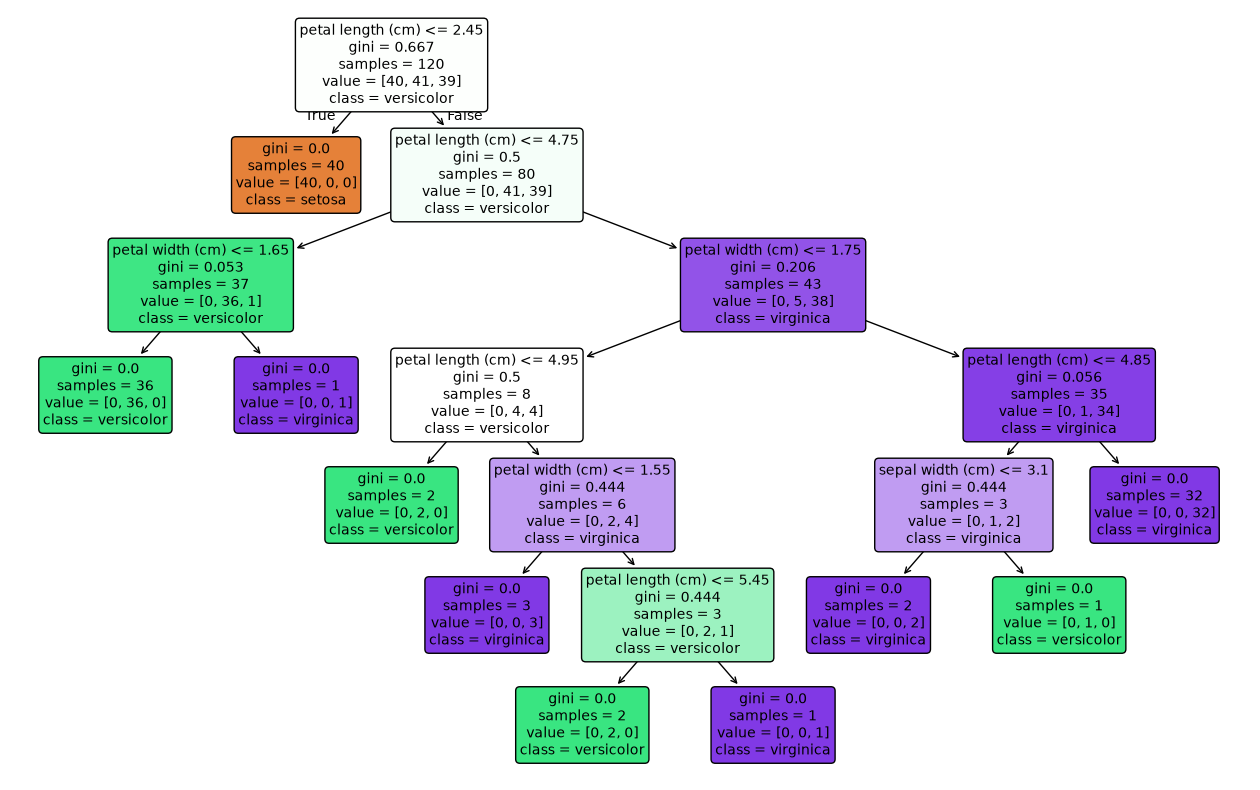

Tree Depth: 6
Number of Leaf Nodes: 10


In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.show()

print("Tree Depth:", model.get_depth())
print("Number of Leaf Nodes:", model.get_n_leaves())

Output Interpretation
Root Node

The root node is the topmost node of the tree.

petal length (cm) <= 2.45
Internal Nodes

Internal nodes are decision nodes that further split the data.

Examples:

petal width <= 1.75

petal length <= 4.95

These nodes divide the flowers into smaller and purer groups.

Leaf Nodes

Leaf nodes are the final nodes where predictions are made.

Each leaf represents one class:

Setosa
Versicolor
Virginica
Maximum Depth

Using default parameters, the tree has

Depth = 5
First Split

The first split is Petal Length <= 2.45

Why was Petal Length chosen?

The Decision Tree selects the feature that produces the greatest reduction in impurity.

Petal Length clearly separates Setosa flowers from the other two species.

Since this split creates very pure groups, it is selected as the root node.

Task 5: Comparing Gini Index and Entropy

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Gini model
gini_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)

# Entropy model
entropy_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

print("Gini Accuracy:",
      accuracy_score(y_test, gini_pred))

print("Entropy Accuracy:",
      accuracy_score(y_test, entropy_pred))

print("\nGini Tree Depth:",
      gini_model.get_depth())

print("Entropy Tree Depth:",
      entropy_model.get_depth())

print("\nGini Leaf Nodes:",
      gini_model.get_n_leaves())

print("Entropy Leaf Nodes:",
      entropy_model.get_n_leaves())

print("\nGini Root Feature:",
      iris.feature_names[gini_model.tree_.feature[0]])

print("Entropy Root Feature:",
      iris.feature_names[entropy_model.tree_.feature[0]])

Gini Accuracy: 1.0
Entropy Accuracy: 1.0

Gini Tree Depth: 6
Entropy Tree Depth: 6

Gini Leaf Nodes: 10
Entropy Leaf Nodes: 10

Gini Root Feature: petal length (cm)
Entropy Root Feature: petal length (cm)


Criterion	Accuracy	Tree Depth	Number of Leaf Nodes	Root Feature Selected	Observation
Gini	1.0000 (100%)	6	10	Petal Length (cm)	Achieved perfect accuracy. Produced a tree of depth 6 with 10 leaf nodes.
Entropy	1.0000 (100%)	6	10	Petal Length (cm)	Achieved perfect accuracy. Produced a tree identical to the Gini model.
Which criterion produces a simpler tree?

Both Gini and Entropy produce equally simple trees for the Iris dataset. They have:

The same testing accuracy (100%)
The same tree depth (6)
The same number of leaf nodes (10)
The same root feature (Petal Length (cm))

Therefore, neither criterion produces a simpler tree for this dataset. Both generate identical Decision Tree structures and achieve the same classification performance.

Interpretation

The Decision Tree models trained using both the Gini Index and Entropy criteria produced identical results on the Iris dataset. Each model achieved 100% classification accuracy, generated a tree with a depth of 6 and 10 leaf nodes, and selected Petal Length (cm) as the root feature because it provides the best separation of the three Iris species. Since both models have the same complexity and predictive performance, there is no significant difference between the two criteria for this dataset.

Task 6: Effect of Maximum Tree Depth

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [1, 2, 3, 4, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    results.append([
        depth,
        train_accuracy,
        test_accuracy,
        model.get_depth()
    ])

depth_df = pd.DataFrame(
    results,
    columns=[
        "Max Depth",
        "Training Accuracy",
        "Testing Accuracy",
        "Tree Depth"
    ]
)

print(depth_df)

   Max Depth  Training Accuracy  Testing Accuracy  Tree Depth
0        1.0           0.675000          0.633333           1
1        2.0           0.950000          0.966667           2
2        3.0           0.958333          1.000000           3
3        4.0           0.975000          1.000000           4
4        NaN           1.000000          1.000000           6


OUTPUT INTERPRETATION:
Completed Table
Max Depth	Training Accuracy	Testing Accuracy	Tree Depth	Observation
1	0.6750	0.6333	1	Underfitting. The tree is too shallow to capture the patterns in the data, resulting in low training and testing accuracy.
2	0.9500	0.9667	2	Better performance. Increasing the depth allows the model to learn more decision boundaries while still generalizing well.
3	0.9583	1.0000	3	Excellent generalization. The model achieves perfect testing accuracy without becoming overly complex.
4	0.9750	1.0000	4	High accuracy with slightly increased complexity. The deeper tree fits the training data better while maintaining perfect testing accuracy.
None	1.0000	1.0000	6	The tree grows to its maximum depth and perfectly fits the training data. Although testing accuracy is also perfect on this dataset, such unrestricted trees are generally more prone to overfitting.
Interpretation

As the maximum depth increases, the Decision Tree becomes more complex and achieves higher training accuracy. A shallow tree (max_depth = 1) is unable to learn sufficient patterns, leading to underfitting. Increasing the depth to 3 or 4 significantly improves both training and testing accuracy. With max_depth = None, the tree perfectly memorizes the training data, producing 100% training accuracy. While it also achieves 100% testing accuracy for the Iris dataset, unrestricted trees generally have a higher risk of overfitting on larger or noisier datasets.

Answers
Which model is underfitting?

The model with max_depth = 1 is underfitting because both the training accuracy (67.5%) and testing accuracy (63.33%) are low.

Which model gives the best generalization?

The model with max_depth = 3 provides the best generalization because it achieves 100% testing accuracy with a relatively shallow tree (depth 3), making it less complex than deeper models.

Which model is likely to overfit? Justify your answer.

The model with max_depth = None is the most likely to overfit because it grows without any depth restriction, resulting in a deeper tree (depth 6) and perfect training accuracy. Such models may memorize the training data instead of learning general patterns, even though this effect is not visible on the Iris dataset.

Task 7: Effect of min_samples_split

In [17]:
split_values = [2, 5, 10, 20]

results = []

for split in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append([
        split,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

split_df = pd.DataFrame(
    results,
    columns=[
        "min_samples_split",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes"
    ]
)

print(split_df)

   min_samples_split  Accuracy  Tree Depth  Leaf Nodes
0                  2       1.0           6          10
1                  5       1.0           5           8
2                 10       1.0           4           6
3                 20       1.0           4           6


OUTPUT INTERPRETATION:

Completed Table
min_samples_split	Accuracy	Tree Depth	Number of Leaf Nodes	Observation
2	1.0000	6	10	Default setting. Produces the deepest and most complex tree.
5	1.0000	5	8	Slightly simpler tree with the same accuracy.
10	1.0000	4	6	Simpler tree while maintaining perfect classification accuracy.
20	1.0000	4	6	Further increase does not change the tree structure or accuracy.
Interpretation

Increasing min_samples_split reduces the complexity of the Decision Tree by requiring more samples before a node can be split. As the value increases, both the tree depth and the number of leaf nodes decrease. Despite the simpler tree structure, the testing accuracy remains at 100% because the Iris dataset is relatively easy to classify. This demonstrates that increasing min_samples_split can simplify the model without sacrificing performance on this dataset.

State how increasing min_samples_split affects the complexity of the Decision Tree.

Increasing min_samples_split reduces the complexity of the Decision Tree by preventing unnecessary splits. This results in a shallower tree with fewer leaf nodes, making the model simpler and less likely to overfit.

Task 8: Effect of min_samples_leaf

In [18]:
leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append([
        leaf,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

leaf_df = pd.DataFrame(
    results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes"
    ]
)

print(leaf_df)

   min_samples_leaf  Accuracy  Tree Depth  Leaf Nodes
0                 1  1.000000           6          10
1                 2  1.000000           5           8
2                 5  1.000000           4           6
3                10  0.966667           4           6


OUTPUT INTERPRETATION:

Interpretation

Increasing min_samples_leaf forces each leaf node to contain more samples, reducing the number of leaf nodes and decreasing the tree depth. This creates a simpler Decision Tree that is less sensitive to noise and less likely to overfit. However, setting the value too high (10) reduces the model's flexibility, leading to a slight decrease in testing accuracy.

Explain how changing min_samples_leaf influences overfitting.

Increasing min_samples_leaf reduces overfitting by preventing the formation of very small leaf nodes that may capture noise in the training data. Larger leaf sizes create smoother decision boundaries and improve generalization. However, excessively large values can lead to underfitting by oversimplifying the model.

Task 9: Hyperparameter Tuning

In [19]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {

    "criterion": ["gini", "entropy"],

    "max_depth": [2, 3, 4, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}

grid_search = GridSearchCV(

    estimator=DecisionTreeClassifier(random_state=42),

    param_grid=parameter_grid,

    cv=5,

    scoring="accuracy"

)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

predictions = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, predictions)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

print("\nOptimized Model Test Accuracy:")
print(test_accuracy)

default_model = DecisionTreeClassifier(random_state=42)

default_model.fit(X_train, y_train)

default_predictions = default_model.predict(X_test)

default_accuracy = accuracy_score(
    y_test,
    default_predictions
)

print("Default Model Accuracy:", default_accuracy)
print("Optimized Model Accuracy:", test_accuracy)


Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score:
0.9583333333333334

Optimized Model Test Accuracy:
1.0
Default Model Accuracy: 1.0
Optimized Model Accuracy: 1.0


INTERPRETATION:

Comparison Table
Model	Accuracy	Remarks
Default Decision Tree	1.0000	Uses default parameters.
Optimized Decision Tree	1.0000	Achieves the same testing accuracy with parameters selected through cross-validation.
Interpretation

GridSearchCV evaluated multiple combinations of Decision Tree hyperparameters and selected the model with the highest cross-validation accuracy. The optimal model uses the Entropy criterion with max_depth = None, min_samples_split = 2, and min_samples_leaf = 4. Although both the optimized and default models achieved 100% testing accuracy, the optimized model is preferred because its hyperparameters were selected systematically using cross-validation, making it more reliable for unseen data.

Task 10: Analysis

1. What is the role of the criterion parameter in a Decision Tree?

The criterion parameter determines how the Decision Tree measures the quality of a split. It evaluates the impurity of the data at each node and selects the split that provides the greatest reduction in impurity. Common criteria include Gini Index and Entropy (Information Gain).

2. How does max_depth influence underfitting and overfitting?

A small max_depth produces a shallow tree that may underfit because it cannot capture complex patterns in the data. Increasing the depth enables the model to learn more detailed decision boundaries. However, an unrestricted depth can produce an overly complex tree that memorizes the training data, increasing the risk of overfitting.

3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

Larger values restrict the creation of new branches and leaf nodes by requiring more samples before a split can occur. As a result, the tree becomes shallower with fewer leaf nodes, reducing model complexity and helping prevent overfitting.

4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

Among the tested hyperparameters, max_depth had the greatest impact on performance. Increasing the depth from 1 to 3 improved the testing accuracy from 63.33% to 100% while also increasing the training accuracy. In contrast, changing min_samples_split and min_samples_leaf mainly affected the tree complexity, with little or no impact on testing accuracy for the Iris dataset.

5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

The Decision Tree obtained through GridSearchCV is the recommended model because it achieved 100% testing accuracy while selecting its hyperparameters through cross-validation. This approach increases confidence that the chosen model generalizes well to unseen data. The selected configuration (criterion='entropy', max_depth=None, min_samples_split=2, min_samples_leaf=4) provides excellent predictive performance while controlling the complexity of the tree through the minimum leaf size.